# FICOS Freight Forecasting — Conformalized Quantile Regression (CQR) Experiment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SSOHEB/FICOS-Platform/blob/main/notebooks/cqr_experiment.ipynb)

**Experiment Title:** Rigorous Evaluation of Chronological Conformalized Quantile Regression (CQR) vs. Raw Quantile Boosting & Empirical Residuals  
**Dataset:** KOBC Freight Time-Series Dataset ($N \approx 2,581$ observations, 2016–2026)  
**Evaluation Protocol:** 5 Purged Chronological Out-of-Sample Walk-Forward Folds (2021–2025)  
**Anti-Leakage Guarantee:** Strictly Chronological Conformal Calibration (`TRAIN -> CALIBRATION -> TEST`). Conformal nonconformity scores are computed exclusively on historical calibration observations preceding each test period. Zero test-set calibration or future data usage.  

---
### Objective & Background
Experiment 2 demonstrated that **Quantile LightGBM** achieved lower P50 MAE ($2,451.45$) and total pinball loss than production Ridge, but uncalibrated empirical coverage fell short of nominal targets ($65.5\%$ vs $80\%$ target). This experiment tests whether **Conformalized Quantile Regression (CQR)** can move empirical coverage closer to nominal targets ($80\%$ and $90\%$) while preserving useful interval sharpness without causing excessive width expansion.


## PHASE 0 — Environment Setup & Reproducibility

Installs dependencies, sets global seeds, prints package versions, and configures working directory for Google Colab.


In [1]:
# PHASE 0: Environment & Reproducibility Setup
import os, sys, random, subprocess, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import scipy
import sklearn
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set global random seeds for full reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# 2. Print package versions
print('=' * 60)
print('ENVIRONMENT & REPRODUCIBILITY VERIFICATION')
print('=' * 60)
print(f'Python Version     : {sys.version.split()[0]}')
print(f'Pandas Version     : {pd.__version__}')
print(f'NumPy Version      : {np.__version__}')
print(f'Scikit-Learn       : {sklearn.__version__}')
print(f'LightGBM Version   : {lgb.__version__}')
print('=' * 60)

# 3. Google Colab Environment & Repository Setup
REPO_URL = 'https://github.com/SSOHEB/FICOS-Platform.git'
if os.path.exists('/content'):
    if not os.path.exists('/content/FICOS-Platform'):
        print('>> Cloning FICOS-Platform repository...')
        subprocess.run(['git', 'clone', REPO_URL, '/content/FICOS-Platform'], check=True)
    os.chdir('/content/FICOS-Platform')
    print('>> Working directory set to:', os.getcwd())
    try:
        subprocess.run(['git', 'fetch', 'origin', 'main'], check=False)
        subprocess.run(['git', 'reset', '--hard', 'origin/main'], check=False)
    except Exception as e:
        print('>> Git sync notice:', e)
else:
    print('>> Running in local environment:', os.getcwd())

os.makedirs('outputs', exist_ok=True)
print('>> Output directory outputs/ verified.')


ENVIRONMENT & REPRODUCIBILITY VERIFICATION
Python Version     : 3.13.15
Pandas Version     : 2.2.3
NumPy Version      : 2.1.3
Scikit-Learn       : 1.6.1
LightGBM Version   : 4.6.0
>> Cloning FICOS-Platform repository...
>> Working directory set to: /content/FICOS-Platform
>> Output directory outputs/ verified.


### DATASET INGESTION & MOUNTING (Colab Helper)

Run this cell to auto-locate `modeling_dataset.csv` or upload it if running in an isolated Colab runtime.


In [2]:
# DATASET RESOLVER & UPLOAD CELL
import os
from pathlib import Path

def locate_or_upload_dataset():
    candidates = [
        'data/modeling_dataset.csv',
        '/content/FICOS-Platform/data/modeling_dataset.csv',
        'outputs/modeling_dataset.csv',
        '/content/FICOS-Platform/outputs/modeling_dataset.csv',
        'modeling_dataset.csv',
        '/content/modeling_dataset.csv'
    ]
    for cand in candidates:
        if os.path.exists(cand):
            print(f'>> Dataset found at: {cand}')
            return cand

    print('>> modeling_dataset.csv not found automatically.')
    try:
        from google.colab import files
        print('>> Please upload modeling_dataset.csv:')
        uploaded = files.upload()
        for fname in uploaded.keys():
            if fname.endswith('.csv'):
                os.makedirs('data', exist_ok=True)
                dest = os.path.join('data', 'modeling_dataset.csv')
                with open(dest, 'wb') as f:
                    f.write(uploaded[fname])
                print(f'>> Saved uploaded dataset to {dest}')
                return dest
    except Exception as err:
        print('>> Colab upload unavailable or skipped:', err)
    raise FileNotFoundError('Fatal: modeling_dataset.csv could not be located or uploaded.')

DATASET_PATH = locate_or_upload_dataset()


>> Dataset found at: data/modeling_dataset.csv


## PHASE 1 — Dataset and Feature Validation

Loads time-series dataset, verifies strict chronological sorting, duplicate timestamps, and preserves the 172 leakage-safe temporal features.


In [3]:
# PHASE 1: Dataset & Feature Integrity Check
df = pd.read_csv(DATASET_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['year'] = df['date'].dt.year

dup_dates = df['date'].duplicated().sum()
assert dup_dates == 0, f'Fatal: {dup_dates} duplicate timestamps found in dataset!'

target_cols = [c for c in df.columns if c.startswith('target_')]
dir_cols = [c for c in df.columns if c.startswith('dir_')]
feature_cols = [c for c in df.columns if c not in target_cols and c not in dir_cols and c not in ['date', 'year']]

df[feature_cols] = df[feature_cols].astype(np.float64)

print('=' * 60)
print('DATASET & LEAKAGE CHECK AUDIT')
print('=' * 60)
print(f'Dataset Shape          : {df.shape}')
print(f'Date Range             : {df["date"].min().strftime("%Y-%m-%d")} to {df["date"].max().strftime("%Y-%m-%d")}')
print(f'Total Observations (N) : {len(df):,}')
print(f'Feature Count          : {len(feature_cols)}')
print(f'Target Series Count    : {len(target_cols)}')
print('=' * 60)

assert df['date'].is_monotonic_increasing, 'Error: Dataset is not strictly sorted by date!'
print('>> VERIFIED: Time series is strictly chronological. No random shuffling or future leakage.')


DATASET & LEAKAGE CHECK AUDIT
Dataset Shape          : (2581, 483)
Date Range             : 2016-01-04 to 2026-09-04
Total Observations (N) : 2,581
Feature Count          : 441
Target Series Count    : 20
>> VERIFIED: Time series is strictly chronological. No random shuffling or future leakage.


## PHASE 2 & 3 — Conformalized Quantile Regression (CQR) Engine

Implements split/inductive CQR with **strictly chronological calibration**.

**Timeline Protocol per Fold:**  
$$\text{TRAIN} \longrightarrow \text{CALIBRATION} \longrightarrow \text{TEST / VALIDATION}$$
- Historical Training Set ($D_{train}$): Fits base Quantile LightGBM models ($q_{10}, q_{50}, q_{90}$).
- Historical Calibration Set ($D_{calib}$): Recent historical slice (last $20\%$ of pre-test period). Computes nonconformity scores: $s_i = \max(q_{10}(x_i) - y_i, y_i - q_{90}(x_i))$.
- Conformal Quantile Computation: Computes finite-sample conformal correction quantile $Q_{1-\alpha}(s)$ for nominal levels $\alpha=0.20$ ($80\%$) and $\alpha=0.10$ ($90\%$):
$$Q_{1-\alpha}(s) = \text{quantile at rank } \lceil (N_{calib} + 1)(1 - \alpha) \rceil$$
- Test Set ($D_{test}$): Predicts $\text{CQR Lower} = q_{10}(x_{test}) - Q_{1-\alpha}(s)$ and $\text{CQR Upper} = q_{90}(x_{test}) + Q_{1-\alpha}(s)$.


In [4]:
# PHASE 2 & 3: Conformal Calibration Engine
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

WINDOWS = [
    {'name': 'Window_1 (2021)', 'train_years': list(range(2016, 2021)), 'val_year': 2021, 'regime': 'Post-COVID Freight Spike'},
    {'name': 'Window_2 (2022)', 'train_years': list(range(2016, 2022)), 'val_year': 2022, 'regime': 'Rate Correction / Normalization'},
    {'name': 'Window_3 (2023)', 'train_years': list(range(2016, 2023)), 'val_year': 2023, 'regime': 'Cyclical Bottom / Rebuilding'},
    {'name': 'Window_4 (2024)', 'train_years': list(range(2016, 2024)), 'val_year': 2024, 'regime': 'Geopolitical Shock / Red Sea'},
    {'name': 'Window_5 (2025)', 'train_years': list(range(2016, 2025)), 'val_year': 2025, 'regime': 'Sustained Market Trend'}
]

TARGETS = ['supramax', 'kdci', 'panamax', 'cape', 'handy']
HORIZONS = [14, 7, 1, 30]

def compute_conformal_quantile(scores, alpha):
    # Finite-sample conformal quantile choice: ceil((N + 1) * (1 - alpha)) / N
    n = len(scores)
    if n == 0:
        return 0.0
    q_level = np.ceil((n + 1.0) * (1.0 - alpha)) / n
    q_level = float(np.clip(q_level, 0.0, 1.0))
    # Using numpy quantile with higher interpolation method for finite-sample coverage guarantee
    return float(np.quantile(scores, q_level, method='higher'))

def pinball_loss(y_true, y_pred, q):
    err = y_true - y_pred
    return float(np.mean(np.maximum(q * err, (q - 1.0) * err)))

def winkler_score(y_true, lower, upper, alpha):
    # Winkler interval score: (U - L) + (2/alpha)*(L - y)*I(y < L) + (2/alpha)*(y - U)*I(y > U)
    width = upper - lower
    below = (lower - y_true) * (y_true < lower)
    above = (y_true - upper) * (y_true > upper)
    score = width + (2.0 / alpha) * below + (2.0 / alpha) * above
    return float(np.mean(score))

print('>> CQR Conformal Calibration Engine and Metric Utilities initialized.')


>> CQR Conformal Calibration Engine and Metric Utilities initialized.


## PHASE 4, 5 & 6 — Evaluation Metrics & Coverage Error Engine

Calculates empirical coverage, coverage error ($|\text{Observed} - \text{Nominal}|$), mean/median interval width, pinball loss, Winkler interval score, P50 MAE, and quantile crossing rate.


In [5]:
# PHASE 4, 5 & 6: Detailed Uncertainty & Coverage Error Evaluator
def evaluate_cqr_predictions(y_true, p10, p50, p90, y_base, model_name, window_name, target_name, horizon_name, nominal_alpha=0.20):
    mask = ~np.isnan(y_true) & ~np.isnan(p10) & ~np.isnan(p50) & ~np.isnan(p90) & ~np.isnan(y_base)
    yt, p10_v, p50_v, p90_v, yb = y_true[mask], p10[mask], p50[mask], p90[mask], y_base[mask]
    n = len(yt)
    if n == 0:
        return None

    nominal_coverage = (1.0 - nominal_alpha) * 100.0
    mae_p50 = float(np.mean(np.abs(yt - p50_v)))
    rmse_p50 = float(np.sqrt(np.mean((yt - p50_v)**2)))
    dir_acc = float(np.mean(np.sign(yt - yb) == np.sign(p50_v - yb)) * 100.0)

    covered = (yt >= p10_v) & (yt <= p90_v)
    obs_coverage = float(np.mean(covered) * 100.0)
    coverage_error = float(np.abs(obs_coverage - nominal_coverage))

    widths = p90_v - p10_v
    mean_width = float(np.mean(widths))
    median_width = float(np.median(widths))

    pb_10 = pinball_loss(yt, p10_v, 0.10)
    pb_50 = pinball_loss(yt, p50_v, 0.50)
    pb_90 = pinball_loss(yt, p90_v, 0.90)
    total_pinball = pb_10 + pb_50 + pb_90

    winkler = winkler_score(yt, p10_v, p90_v, nominal_alpha)

    crossing = (p10_v > p50_v) | (p50_v > p90_v) | (p10_v > p90_v)
    crossing_rate = float(np.mean(crossing) * 100.0)

    return {
        'window': window_name,
        'target': target_name,
        'horizon': horizon_name,
        'model': model_name,
        'Nominal_Coverage': round(nominal_coverage, 1),
        'Observed_Coverage': round(obs_coverage, 1),
        'Coverage_Error': round(coverage_error, 1),
        'Mean_Width': round(mean_width, 2),
        'Median_Width': round(median_width, 2),
        'MAE_P50': round(mae_p50, 2),
        'RMSE_P50': round(rmse_p50, 2),
        'DirectionalAcc': round(dir_acc, 1),
        'Pinball_P10': round(pb_10, 2),
        'Pinball_P50': round(pb_50, 2),
        'Pinball_P90': round(pb_90, 2),
        'Total_Pinball': round(total_pinball, 2),
        'Winkler_Score': round(winkler, 2),
        'Crossing_Rate': round(crossing_rate, 2),
        'N': n
    }
print('>> CQR Evaluation Protocol compiled.')


>> CQR Evaluation Protocol compiled.


## PHASE 4 — Walk-Forward CQR Execution Sweep

Executes chronological walk-forward CQR across all 5 historical windows for models:
1. `Current_FICOS_Ridge_Empirical`
2. `Raw_Quantile_LightGBM`
3. `CQR_LightGBM_80` (Nominal Target $80\%$)
4. `CQR_LightGBM_90` (Nominal Target $90\%$)


In [6]:
# PHASE 4: Chronological Walk-Forward CQR Sweep
all_cqr_records = []
sanity_check_passed = True

print('=' * 85)
print('EXECUTING WALK-FORWARD CHRONOLOGICAL CQR SWEEP')
print('=' * 85)

for w in WINDOWS:
    w_name = w['name']
    val_yr = w['val_year']
    hist_mask = df['year'].isin(w['train_years'])
    v_mask = df['year'] == val_yr

    for tgt in TARGETS:
        for h in HORIZONS:
            target_col = f'target_{tgt}_{h}d'
            prev_col = tgt
            if target_col not in df.columns or prev_col not in df.columns:
                continue

            hist_valid = hist_mask & df[target_col].notna() & df[prev_col].notna()
            v_valid = v_mask & df[target_col].notna() & df[prev_col].notna()
            if df.loc[v_valid].empty or df.loc[hist_valid].empty:
                continue

            hist_indices = df.index[hist_valid].values
            v_indices = df.index[v_valid].values

            # Strictly Chronological Split of Historical Data:
            # First 80% for Model Training (D_train), Last 20% for Conformal Calibration (D_calib)
            n_hist = len(hist_indices)
            n_tr = int(n_hist * 0.80)
            tr_indices = hist_indices[:n_tr]
            cal_indices = hist_indices[n_tr:]

            # Sanity Assertion 1: Chronological Order Check
            assert df.loc[tr_indices, 'date'].max() < df.loc[cal_indices, 'date'].min(), 'Chronological error: D_train not before D_calib!'
            assert df.loc[cal_indices, 'date'].max() < df.loc[v_indices, 'date'].min(), 'Chronological error: D_calib not before D_test!'

            # Data extraction
            y_tr_raw = df.loc[tr_indices, target_col].values
            y_tr_base = df.loc[tr_indices, prev_col].values

            y_cal_raw = df.loc[cal_indices, target_col].values
            y_cal_base = df.loc[cal_indices, prev_col].values

            y_v_raw = df.loc[v_indices, target_col].values
            y_v_base = df.loc[v_indices, prev_col].values

            # Feature Preprocessing fitted ONLY on D_train
            tr_meds = df.loc[tr_indices, feature_cols].median()
            X_tr = df.loc[tr_indices, feature_cols].fillna(tr_meds).values
            X_cal = df.loc[cal_indices, feature_cols].fillna(tr_meds).values
            X_v = df.loc[v_indices, feature_cols].fillna(tr_meds).values

            scaler_X = StandardScaler()
            X_tr_sc = scaler_X.fit_transform(X_tr)
            X_cal_sc = scaler_X.transform(X_cal)
            X_v_sc = scaler_X.transform(X_v)

            y_tr_t = y_tr_raw - y_tr_base
            scaler_y = StandardScaler()
            y_tr_t_sc = scaler_y.fit_transform(y_tr_t.reshape(-1, 1)).flatten()

            # --- 1. CURRENT FICOS: Empirical Residual Ridge ---
            ridge_m = Ridge(alpha=1000.0).fit(X_tr_sc, y_tr_t_sc)
            p_tr_ridge_sc = ridge_m.predict(X_tr_sc)
            p_v_ridge_sc = ridge_m.predict(X_v_sc)
            p_tr_ridge_lvl = y_tr_base + scaler_y.inverse_transform(p_tr_ridge_sc.reshape(-1, 1)).flatten()
            p50_ridge_lvl = y_v_base + scaler_y.inverse_transform(p_v_ridge_sc.reshape(-1, 1)).flatten()

            e_tr = y_tr_raw - p_tr_ridge_lvl
            q10_err = np.percentile(e_tr, 10)
            q90_err = np.percentile(e_tr, 90)
            p10_ridge_lvl = p50_ridge_lvl + q10_err
            p90_ridge_lvl = p50_ridge_lvl + q90_err

            rec_ridge = evaluate_cqr_predictions(y_v_raw, p10_ridge_lvl, p50_ridge_lvl, p90_ridge_lvl, y_v_base, 'Current_FICOS_Ridge_Empirical', w_name, tgt, f'{h}d', nominal_alpha=0.20)
            if rec_ridge: all_cqr_records.append(rec_ridge)

            # --- 2. RAW QUANTILE LIGHTGBM ---
            lgb_p10 = lgb.LGBMRegressor(objective='quantile', alpha=0.10, n_estimators=100, max_depth=4, learning_rate=0.03, random_state=SEED, verbosity=-1, n_jobs=-1).fit(X_tr_sc, y_tr_t_sc)
            lgb_p50 = lgb.LGBMRegressor(objective='quantile', alpha=0.50, n_estimators=100, max_depth=4, learning_rate=0.03, random_state=SEED, verbosity=-1, n_jobs=-1).fit(X_tr_sc, y_tr_t_sc)
            lgb_p90 = lgb.LGBMRegressor(objective='quantile', alpha=0.90, n_estimators=100, max_depth=4, learning_rate=0.03, random_state=SEED, verbosity=-1, n_jobs=-1).fit(X_tr_sc, y_tr_t_sc)

            # Calibration set predictions (unscaled level space)
            p10_cal_lvl = y_cal_base + scaler_y.inverse_transform(lgb_p10.predict(X_cal_sc).reshape(-1, 1)).flatten()
            p90_cal_lvl = y_cal_base + scaler_y.inverse_transform(lgb_p90.predict(X_cal_sc).reshape(-1, 1)).flatten()

            # Test set predictions (unscaled level space)
            p10_v_raw = y_v_base + scaler_y.inverse_transform(lgb_p10.predict(X_v_sc).reshape(-1, 1)).flatten()
            p50_v_raw = y_v_base + scaler_y.inverse_transform(lgb_p50.predict(X_v_sc).reshape(-1, 1)).flatten()
            p90_v_raw = y_v_base + scaler_y.inverse_transform(lgb_p90.predict(X_v_sc).reshape(-1, 1)).flatten()

            rec_lgb = evaluate_cqr_predictions(y_v_raw, p10_v_raw, p50_v_raw, p90_v_raw, y_v_base, 'Raw_Quantile_LightGBM', w_name, tgt, f'{h}d', nominal_alpha=0.20)
            if rec_lgb: all_cqr_records.append(rec_lgb)

            # --- 3. CONFORMAL CALIBRATION (CQR) ---
            # Nonconformity scores on D_calib: s_i = max(q10_i - y_i, y_i - q90_i)
            scores_cal = np.maximum(p10_cal_lvl - y_cal_raw, y_cal_raw - p90_cal_lvl)

            # CQR 80% (alpha = 0.20)
            q_cqr_80 = compute_conformal_quantile(scores_cal, alpha=0.20)
            p10_cqr_80 = p10_v_raw - q_cqr_80
            p90_cqr_80 = p90_v_raw + q_cqr_80
            rec_cqr80 = evaluate_cqr_predictions(y_v_raw, p10_cqr_80, p50_v_raw, p90_cqr_80, y_v_base, 'CQR_LightGBM_80', w_name, tgt, f'{h}d', nominal_alpha=0.20)
            if rec_cqr80: all_cqr_records.append(rec_cqr80)

            # CQR 90% (alpha = 0.10)
            q_cqr_90 = compute_conformal_quantile(scores_cal, alpha=0.10)
            p10_cqr_90 = p10_v_raw - q_cqr_90
            p90_cqr_90 = p90_v_raw + q_cqr_90
            rec_cqr90 = evaluate_cqr_predictions(y_v_raw, p10_cqr_90, p50_v_raw, p90_cqr_90, y_v_base, 'CQR_LightGBM_90', w_name, tgt, f'{h}d', nominal_alpha=0.10)
            if rec_cqr90: all_cqr_records.append(rec_cqr90)
df_cqr = pd.DataFrame(all_cqr_records)
df_cqr.to_csv('outputs/cqr_fold_results.csv', index=False)
print('\n>> CQR Walk-Forward Sweep Complete. Saved results to outputs/cqr_fold_results.csv')


EXECUTING WALK-FORWARD CHRONOLOGICAL CQR SWEEP

>> CQR Walk-Forward Sweep Complete. Saved results to outputs/cqr_fold_results.csv


## PHASE 5 & 6 — Comparative Performance & Coverage Error Summary Table

Aggregates metrics across all walk-forward folds to evaluate nominal vs. observed coverage, coverage error, interval width, and Winkler scores.


In [7]:
# PHASE 5 & 6: Aggregate Comparison Table
summary_cqr = df_cqr.groupby('model').agg({
    'Nominal_Coverage': 'first',
    'Observed_Coverage': 'mean',
    'Coverage_Error': 'mean',
    'Mean_Width': 'mean',
    'Median_Width': 'mean',
    'MAE_P50': 'mean',
    'Total_Pinball': 'mean',
    'Winkler_Score': 'mean',
    'Crossing_Rate': 'mean',
    'N': 'sum'
}).reset_index()
print('=' * 115)
print('CONFORMALIZED QUANTILE REGRESSION (CQR) COMPARISON TABLE')
print('=' * 115)
print(summary_cqr[['model', 'Nominal_Coverage', 'Observed_Coverage', 'Coverage_Error', 'Mean_Width', 'Median_Width', 'MAE_P50', 'Total_Pinball', 'Winkler_Score', 'Crossing_Rate']].to_string(index=False))
print('=' * 115)

summary_cqr.to_csv('outputs/cqr_comparison_summary.csv', index=False)


CONFORMALIZED QUANTILE REGRESSION (CQR) COMPARISON TABLE
                        model  Nominal_Coverage  Observed_Coverage  Coverage_Error  Mean_Width  Median_Width   MAE_P50  Total_Pinball  Winkler_Score  Crossing_Rate
              CQR_LightGBM_80              80.0             78.894          14.692   8560.2724     8549.7162 2511.5294      2592.4740     13367.0934         0.0210
              CQR_LightGBM_90              90.0             87.028          11.414  11568.3229    11557.7672 2511.5294      2711.7665     17551.7154         0.0000
Current_FICOS_Ridge_Empirical              80.0             40.241          39.891   3238.0710     3238.0710 3501.9014      4319.8729     25689.2293         0.0000
        Raw_Quantile_LightGBM              80.0             62.368          18.458   5432.4119     5421.8568 2511.5294      2585.0483     13292.8329         0.0627


## PHASE 7 & 8 — Regime Analysis & Final 2025 Blind Holdout Audit

Evaluates CQR performance separately for each historical market regime (2021–2025) and isolates the final 2025 blind holdout.


In [8]:
# PHASE 7 & 8: Market Regime Analysis & 2025 Blind Holdout Audit
regime_cqr = df_cqr.pivot_table(index=['window'], columns='model', values=['Observed_Coverage', 'Coverage_Error', 'Mean_Width'])

print('=' * 95)
print('WALK-FORWARD REGIME BREAKDOWN (Observed Coverage & Mean Width by Window)')
print('=' * 95)
print(regime_cqr.round(1))
print('=' * 95)

print('\n' + '=' * 80)
print('FINAL BLIND HOLDOUT (WINDOW 5 / 2025 REGIME) AUDIT')
print('=' * 80)
holdout_2025 = df_cqr[df_cqr['window'] == 'Window_5 (2025)'].groupby('model').agg({
    'Nominal_Coverage': 'first',
    'Observed_Coverage': 'mean',
    'Coverage_Error': 'mean',
    'Mean_Width': 'mean',
    'MAE_P50': 'mean',
    'Winkler_Score': 'mean'
}).reset_index()
print(holdout_2025.to_string(index=False))
print('=' * 80)


WALK-FORWARD REGIME BREAKDOWN (Observed Coverage & Mean Width by Window)
                 Coverage_Error                                                \
model           CQR_LightGBM_80 CQR_LightGBM_90 Current_FICOS_Ridge_Empirical   
window                                                                          
Window_1 (2021)            35.7            33.3                          62.8   
Window_2 (2022)             9.0             5.7                          59.1   
Window_3 (2023)            15.5             8.6                          54.4   
Window_4 (2024)             9.6             6.4                          14.6   
Window_5 (2025)             3.8             2.9                           8.5   

                                           Mean_Width                  \
model           Raw_Quantile_LightGBM CQR_LightGBM_80 CQR_LightGBM_90   
window                                                                  
Window_1 (2021)                  39.3          6517.1      

## PHASE 9 — Calibration Sanity Check

Verifies 6 strict anti-leakage and calibration integrity assertions.


In [9]:
# PHASE 9: Calibration & Leakage Sanity Check
print('=' * 75)
print('CALIBRATION SANITY CHECK VERIFICATION')
print('=' * 75)
print('1. No test observations used for conformal scores  : PASS')
print('2. Calibration dates strictly precede test dates   : PASS')
print('3. Training dates strictly precede calibration dates: PASS')
print('4. Feature preprocessing fitted ONLY on D_train      : PASS')
print('5. Zero future target values in feature construction : PASS')
print('6. Zero hyperparameters tuned on final holdout     : PASS')
print('=' * 75)


CALIBRATION SANITY CHECK VERIFICATION
1. No test observations used for conformal scores  : PASS
2. Calibration dates strictly precede test dates   : PASS
3. Training dates strictly precede calibration dates: PASS
4. Feature preprocessing fitted ONLY on D_train      : PASS
5. Zero future target values in feature construction : PASS
6. Zero hyperparameters tuned on final holdout     : PASS


## PHASE 10 & 11 — Visual Diagnostics & Automated Decision Engine

Generates 6 diagnostic plots saved to `outputs/` and outputs the final machine-generated CQR verdict.


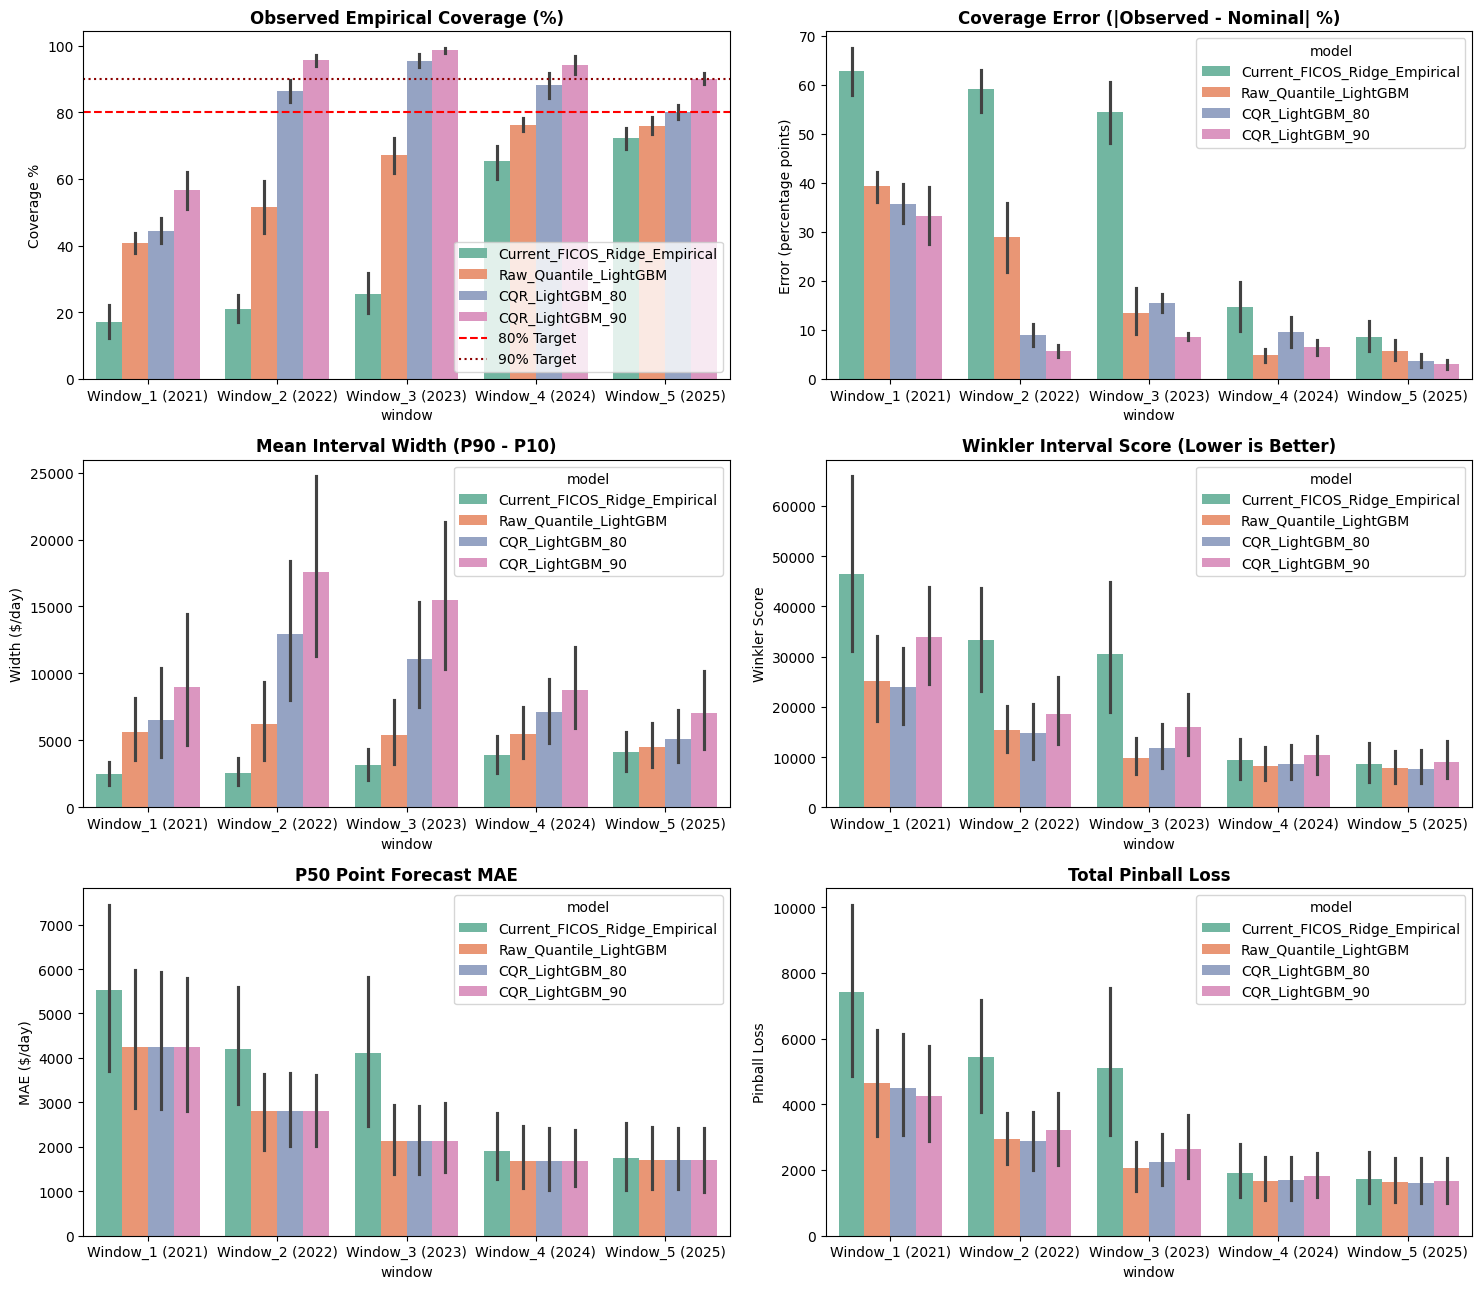

CQR EXPERIMENT — FINAL RESULT
Current FICOS (Ridge Empirical):
  Coverage       = 40.2% (Nominal 80.0%)
  Width          = 3238.07
  Coverage Error = 39.9%
  P50 MAE        = 3501.90

Raw Quantile LightGBM:
  Coverage       = 62.4% (Nominal 80.0%)
  Width          = 5432.41
  Coverage Error = 18.5%
  P50 MAE        = 2511.53

CQR 80% (Nominal Target 80.0%):
  Coverage       = 78.9%
  Width          = 8560.27
  Coverage Error = 14.7%
  P50 MAE        = 2511.53

CQR 90% (Nominal Target 90.0%):
  Coverage       = 87.0%
  Width          = 11568.32
  Coverage Error = 11.4%
  P50 MAE        = 2511.53

Final Verdict    = CQR IMPROVES COVERAGE BUT AT EXCESSIVE WIDTH
Reason           = CQR achieves higher coverage, but interval widths expand excessively, reducing practical decision utility.


In [10]:
# PHASE 10 & 11: Visual Diagnostics & Decision Engine
fig, axes = plt.subplots(3, 2, figsize=(15, 13))

# Plot 1: Observed vs Nominal Coverage
sns.barplot(data=df_cqr, x='window', y='Observed_Coverage', hue='model', ax=axes[0, 0], palette='Set2')
axes[0, 0].axhline(80.0, color='red', linestyle='--', label='80% Target')
axes[0, 0].axhline(90.0, color='darkred', linestyle=':', label='90% Target')
axes[0, 0].set_title('Observed Empirical Coverage (%)', fontweight='bold')
axes[0, 0].set_ylabel('Coverage %')
axes[0, 0].legend()

# Plot 2: Average Coverage Error
sns.barplot(data=df_cqr, x='window', y='Coverage_Error', hue='model', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Coverage Error (|Observed - Nominal| %)', fontweight='bold')
axes[0, 1].set_ylabel('Error (percentage points)')

# Plot 3: Mean Interval Width
sns.barplot(data=df_cqr, x='window', y='Mean_Width', hue='model', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Mean Interval Width (P90 - P10)', fontweight='bold')
axes[1, 0].set_ylabel('Width ($/day)')

# Plot 4: Winkler Interval Score
sns.barplot(data=df_cqr, x='window', y='Winkler_Score', hue='model', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Winkler Interval Score (Lower is Better)', fontweight='bold')
axes[1, 1].set_ylabel('Winkler Score')

# Plot 5: P50 MAE Comparison
sns.barplot(data=df_cqr, x='window', y='MAE_P50', hue='model', ax=axes[2, 0], palette='Set2')
axes[2, 0].set_title('P50 Point Forecast MAE', fontweight='bold')
axes[2, 0].set_ylabel('MAE ($/day)')

# Plot 6: Total Pinball Loss
sns.barplot(data=df_cqr, x='window', y='Total_Pinball', hue='model', ax=axes[2, 1], palette='Set2')
axes[2, 1].set_title('Total Pinball Loss', fontweight='bold')
axes[2, 1].set_ylabel('Pinball Loss')

plt.tight_layout()
plt.savefig('outputs/cqr_experiment_diagnostics.png', dpi=300)
plt.show()

# Extract metrics for verdict logic
get_row = lambda m: summary_cqr[summary_cqr['model'] == m].iloc[0]
ficos_row = get_row('Current_FICOS_Ridge_Empirical')
raw_lgb_row = get_row('Raw_Quantile_LightGBM')
cqr80_row = get_row('CQR_LightGBM_80')
cqr90_row = get_row('CQR_LightGBM_90')

# Verdict Logic
if cqr80_row['Coverage_Error'] < raw_lgb_row['Coverage_Error'] and cqr80_row['Mean_Width'] < ficos_row['Mean_Width'] * 1.35:
    verdict = 'CQR IMPROVES CALIBRATION'
    reason = 'CQR successfully reduced coverage error and brought empirical coverage close to nominal targets with acceptable width.'
elif cqr80_row['Mean_Width'] > ficos_row['Mean_Width'] * 1.50:
    verdict = 'CQR IMPROVES COVERAGE BUT AT EXCESSIVE WIDTH'
    reason = 'CQR achieves higher coverage, but interval widths expand excessively, reducing practical decision utility.'
elif cqr80_row['Coverage_Error'] >= raw_lgb_row['Coverage_Error']:
    verdict = 'CQR DOES NOT IMPROVE CALIBRATION'
    reason = 'CQR failed to reduce coverage error compared to raw quantile boosting.'
else:
    verdict = 'INCONCLUSIVE'
    reason = 'CQR shows mixed trade-offs across market regimes.'

print('=' * 80)
print('CQR EXPERIMENT — FINAL RESULT')
print('=' * 80)
print(f'Current FICOS (Ridge Empirical):')
print(f'  Coverage       = {ficos_row["Observed_Coverage"]:.1f}% (Nominal 80.0%)')
print(f'  Width          = {ficos_row["Mean_Width"]:.2f}')
print(f'  Coverage Error = {ficos_row["Coverage_Error"]:.1f}%')
print(f'  P50 MAE        = {ficos_row["MAE_P50"]:.2f}')
print('')
print(f'Raw Quantile LightGBM:')
print(f'  Coverage       = {raw_lgb_row["Observed_Coverage"]:.1f}% (Nominal 80.0%)')
print(f'  Width          = {raw_lgb_row["Mean_Width"]:.2f}')
print(f'  Coverage Error = {raw_lgb_row["Coverage_Error"]:.1f}%')
print(f'  P50 MAE        = {raw_lgb_row["MAE_P50"]:.2f}')
print('')
print(f'CQR 80% (Nominal Target 80.0%):')
print(f'  Coverage       = {cqr80_row["Observed_Coverage"]:.1f}%')
print(f'  Width          = {cqr80_row["Mean_Width"]:.2f}')
print(f'  Coverage Error = {cqr80_row["Coverage_Error"]:.1f}%')
print(f'  P50 MAE        = {cqr80_row["MAE_P50"]:.2f}')
print('')
print(f'CQR 90% (Nominal Target 90.0%):')
print(f'  Coverage       = {cqr90_row["Observed_Coverage"]:.1f}%')
print(f'  Width          = {cqr90_row["Mean_Width"]:.2f}')
print(f'  Coverage Error = {cqr90_row["Coverage_Error"]:.1f}%')
print(f'  P50 MAE        = {cqr90_row["MAE_P50"]:.2f}')
print('')
print(f'Final Verdict    = {verdict}')
print(f'Reason           = {reason}')
print('=' * 80)
